<a href="https://colab.research.google.com/github/JV-ANUBIS/Sistemas-inteligentes/blob/main/Projeto3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3º Projeto - Sistemas Inteligentes

## Classificação da qualidade de vinhos utilizando k-NN

Este projeto tem como objetivo construir um modelo de classificação de vinhos em três categorias de qualidade: ruim, médio e bom, utilizando o algoritmo k-NN e atributos físico-químicos do dataset Wine Quality.

In [2]:
# Importação das bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [3]:
from google.colab import files

uploaded = files.upload()

Saving winequality-red.csv to winequality-red.csv


In [4]:
df = pd.read_csv('winequality-red.csv', sep=';')

df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
df.shape

(1599, 12)

In [6]:
# Recodificação da variável quality em três classes

def classificar_qualidade(valor):
    if valor <= 5:
        return 'ruim'
    elif valor <= 7:
        return 'medio'
    else:
        return 'bom'

df['classe_qualidade'] = df['quality'].apply(classificar_qualidade)

# Visualizando as primeiras linhas com a nova classe
df[['quality', 'classe_qualidade']].head(10)

,quality,classe_qualidade
0,5,ruim
1,5,ruim
2,5,ruim
3,6,medio
4,5,ruim
5,5,ruim
6,5,ruim
7,7,medio
8,7,medio
9,5,ruim


In [7]:
# Verificando a distribuição das classes

df['classe_qualidade'].value_counts()

,count
classe_qualidade,
medio,837
ruim,744
bom,18


In [9]:
# Separando atributos de entrada (X) e classe de saída (y)

X = df.drop(['quality', 'classe_qualidade'], axis=1)
y = df['classe_qualidade']

# Visualizando os nomes dos atributos
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [10]:
# Normalização dos atributos com Min-MaxScaler

scaler = MinMaxScaler()

X_normalizado = scaler.fit_transform(X)

# Convertendo novamente para DataFrame para facilitar a visualização
X_normalizado = pd.DataFrame(X_normalizado, columns=X.columns)

X_normalizado.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.247788,0.397260,0.00,0.068493,0.106845,0.140845,0.098940,0.567548,0.606299,0.137725,0.153846
1,0.283186,0.520548,0.00,0.116438,0.143573,0.338028,0.215548,0.494126,0.362205,0.209581,0.215385
2,0.283186,0.438356,0.04,0.095890,0.133556,0.197183,0.169611,0.508811,0.409449,0.191617,0.215385
3,0.584071,0.109589,0.56,0.068493,0.105175,0.225352,0.190813,0.582232,0.330709,0.149701,0.215385
4,0.247788,0.397260,0.00,0.068493,0.106845,0.140845,0.098940,0.567548,0.606299,0.137725,0.153846


In [11]:
# Verificando valores mínimos e máximos após a normalização

print("Valores mínimos:")
print(X_normalizado.min())

print("\nValores máximos:")
print(X_normalizado.max())

Valores mínimos:
fixed acidity           0.0
volatile acidity        0.0
citric acid             0.0
residual sugar          0.0
chlorides               0.0
free sulfur dioxide     0.0
total sulfur dioxide    0.0
density                 0.0
pH                      0.0
sulphates               0.0
alcohol                 0.0
dtype: float64

Valores máximos:
fixed acidity           1.0
volatile acidity        1.0
citric acid             1.0
residual sugar          1.0
chlorides               1.0
free sulfur dioxide     1.0
total sulfur dioxide    1.0
density                 1.0
pH                      1.0
sulphates               1.0
alcohol                 1.0
dtype: float64


A normalização dos dados foi realizada utilizando o método Min-MaxScaler, que transforma os valores dos atributos para uma escala entre 0 e 1. Essa etapa é obrigatória para o algoritmo k-NN, pois ele classifica as amostras com base em medidas de distância. Sem a normalização, atributos com valores numéricos maiores poderiam influenciar excessivamente o cálculo da distância, prejudicando o desempenho do modelo.

In [12]:
# Divisão dos dados em treino e teste

X_train, X_test, y_train, y_test = train_test_split(
    X_normalizado,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Verificando os tamanhos dos conjuntos
print("Tamanho do conjunto de treino:", X_train.shape)
print("Tamanho do conjunto de teste:", X_test.shape)

Tamanho do conjunto de treino: (1279, 11)
Tamanho do conjunto de teste: (320, 11)


In [13]:
# Verificando a proporção das classes no conjunto completo, treino e teste

print("Distribuição no conjunto completo:")
print(y.value_counts(normalize=True))

print("\nDistribuição no conjunto de treino:")
print(y_train.value_counts(normalize=True))

print("\nDistribuição no conjunto de teste:")
print(y_test.value_counts(normalize=True))

Distribuição no conjunto completo:
classe_qualidade
medio    0.523452
ruim     0.465291
bom      0.011257
Name: proportion, dtype: float64

Distribuição no conjunto de treino:
classe_qualidade
medio    0.523847
ruim     0.465207
bom      0.010946
Name: proportion, dtype: float64

Distribuição no conjunto de teste:
classe_qualidade
medio    0.521875
ruim     0.465625
bom      0.012500
Name: proportion, dtype: float64


Após a preparação dos dados, o conjunto foi dividido em 80% para treinamento e 20% para teste. Foi utilizada a divisão estratificada, garantindo que a proporção das classes ruim, médio e bom fosse preservada tanto no conjunto de treino quanto no conjunto de teste. Essa estratégia é importante porque o dataset apresenta desbalanceamento entre as classes, especialmente com menor quantidade de amostras da classe bom.

In [14]:
# Testando diferentes valores de k com validação cruzada

valores_k = [1, 3, 5, 7, 11]

acuracias_medias = []

for k in valores_k:
    modelo = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        modelo,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    acuracias_medias.append(scores.mean())

    print(f"k = {k} | Acurácia média = {scores.mean():.4f}")

k = 1 | Acurácia média = 0.7170
k = 3 | Acurácia média = 0.6810
k = 5 | Acurácia média = 0.6810
k = 7 | Acurácia média = 0.6857
k = 11 | Acurácia média = 0.6998


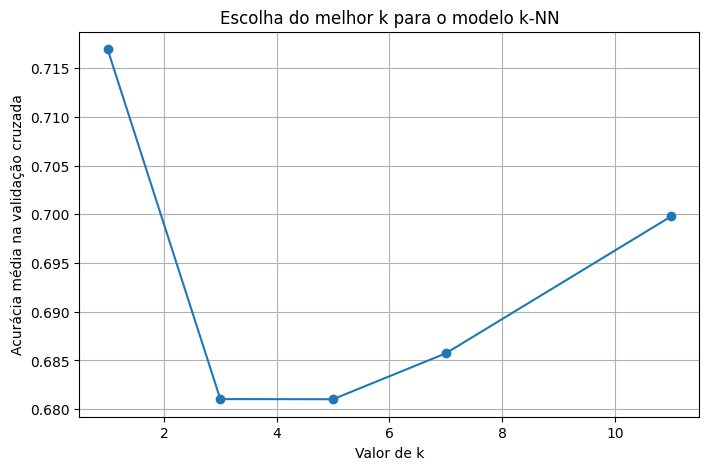

In [15]:
# Gráfico da acurácia média em função de k

plt.figure(figsize=(8, 5))
plt.plot(valores_k, acuracias_medias, marker='o')
plt.xlabel('Valor de k')
plt.ylabel('Acurácia média na validação cruzada')
plt.title('Escolha do melhor k para o modelo k-NN')
plt.grid(True)
plt.show()

In [16]:
# Escolhendo o melhor valor de k

melhor_k = valores_k[acuracias_medias.index(max(acuracias_medias))]

print("Melhor valor de k:", melhor_k)
print("Melhor acurácia média:", max(acuracias_medias))

Melhor valor de k: 1
Melhor acurácia média: 0.7169638480392158


Foram testados diferentes valores de k: 1, 3, 5, 7 e 11. A escolha do melhor valor foi feita utilizando validação cruzada com 5 folds sobre o conjunto de treino. Esse procedimento permite avaliar o desempenho médio do modelo em diferentes divisões dos dados, reduzindo a dependência de uma única separação treino/teste.

Para valores muito baixos de k, como k = 1, o modelo tende a ficar muito sensível a ruídos e amostras isoladas, podendo causar sobreajuste. Já para valores muito altos de k, o modelo passa a considerar muitos vizinhos, podendo suavizar demais a fronteira de decisão e perder capacidade de distinguir corretamente as classes.

In [18]:
# Treinando o modelo final com o melhor valor de k

modelo_final = KNeighborsClassifier(n_neighbors=melhor_k)

modelo_final.fit(X_train, y_train)

# Fazendo previsões no conjunto de teste
y_pred = modelo_final.predict(X_test)

In [19]:
# Acurácia no conjunto de teste

acuracia_teste = accuracy_score(y_test, y_pred)

print(f"Acurácia no conjunto de teste: {acuracia_teste:.4f}")

Acurácia no conjunto de teste: 0.7750


In [20]:
# Matriz de confusão

matriz = confusion_matrix(y_test, y_pred, labels=['ruim', 'medio', 'bom'])

matriz_confusao = pd.DataFrame(
    matriz,
    index=['Real ruim', 'Real medio', 'Real bom'],
    columns=['Predito ruim', 'Predito medio', 'Predito bom']
)

matriz_confusao

,Predito ruim,Predito medio,Predito bom
Real ruim,114,35,0
Real medio,32,134,1
Real bom,0,4,0


In [21]:
# Relatório de classificação: precisão, recall e F1-score

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         bom       0.00      0.00      0.00         4
       medio       0.77      0.80      0.79       167
        ruim       0.78      0.77      0.77       149

    accuracy                           0.78       320
   macro avg       0.52      0.52      0.52       320
weighted avg       0.77      0.78      0.77       320



A avaliação do modelo k-NN no conjunto de teste apresentou acurácia de 78%. A matriz de confusão indicou que o modelo obteve melhor desempenho na identificação das classes ruim e médio. Os principais erros ocorreram entre essas duas classes, com 35 vinhos ruins classificados como médio e 32 vinhos médios classificados como ruim. Esse comportamento pode ser explicado pela proximidade entre essas categorias na escala original de qualidade, uma vez que vinhos com notas próximas tendem a apresentar características físico-químicas semelhantes.

A classe bom apresentou o pior desempenho, com precisão, recall e F1-score iguais a zero. Isso se deve principalmente ao baixo número de amostras dessa classe no conjunto de teste, apenas quatro, o que dificultou o aprendizado e a generalização do modelo para vinhos de alta qualidade. Assim, apesar da acurácia geral de 78%, o modelo mostrou limitações para lidar com classes desbalanceadas.

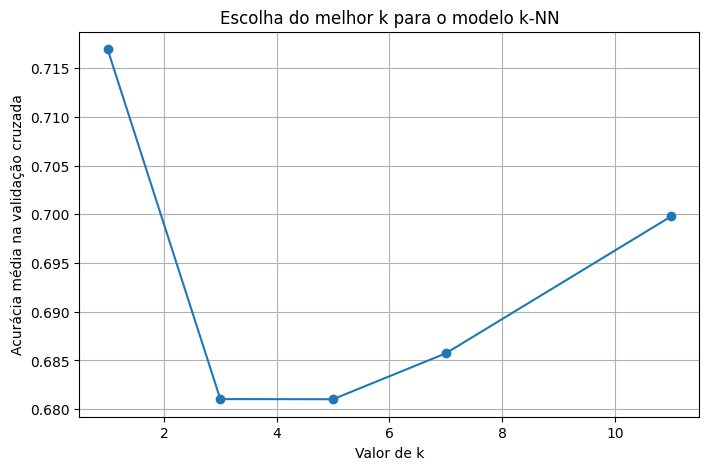

In [22]:
# Salvando o gráfico de acurácia por k

plt.figure(figsize=(8, 5))
plt.plot(valores_k, acuracias_medias, marker='o')
plt.xlabel('Valor de k')
plt.ylabel('Acurácia média na validação cruzada')
plt.title('Escolha do melhor k para o modelo k-NN')
plt.grid(True)

plt.savefig('grafico_acuracia_k.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
# Salvando a matriz de confusão em CSV

matriz_confusao.to_csv('matriz_confusao.csv')

Neste projeto, foi desenvolvido um modelo de classificação de vinhos utilizando o algoritmo k-NN, com o objetivo de classificar as amostras em três categorias de qualidade: ruim, médio e bom. Inicialmente, a variável quality foi recodificada em três classes, conforme solicitado no enunciado. Em seguida, os atributos físico-químicos foram normalizados com Min-MaxScaler, etapa essencial para o k-NN, pois o algoritmo utiliza medidas de distância para realizar a classificação.

Após a divisão estratificada dos dados em treino e teste, diferentes valores de k foram avaliados por meio de validação cruzada com 5 folds. O modelo final foi treinado com o melhor valor de k encontrado e avaliado no conjunto de teste. Os resultados apresentaram acurácia geral de aproximadamente 78%, indicando um desempenho satisfatório para as classes ruim e médio.

Entretanto, o modelo apresentou dificuldade para classificar corretamente a classe bom, que possuía poucas amostras no conjunto de teste. Esse resultado mostra uma limitação do k-NN diante de dados desbalanceados. Portanto, embora o k-NN tenha se mostrado adequado como abordagem inicial para o problema, técnicas adicionais, como balanceamento de classes, ajuste de hiperparâmetros e comparação com outros algoritmos, poderiam melhorar o desempenho do modelo.